<a href="https://colab.research.google.com/github/twyeh/university-physics/blob/%E9%9B%BB%E7%A3%81%E5%AD%B8/%E9%9D%9C%E9%9B%BB%E5%A0%B4%E8%A8%88%E7%AE%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 前言
利用符號計算程式協助計算複雜靜電場問題可以減少學習電場計算時遇到的數學困擾。
## 點電荷庫倫定律
根據庫倫定律，假設有一點電荷$Q$位在$S=(x,y,z)$,在空間一點$P=(x_p,y_p,z_p})$,則在$P$點的電場為

\begin{equation}
\vec{E}(x_p,y_p,z_p)=k\frac{Q((x_p-x)\hat{i}+(y_p-y)\hat{j}+(z_p-z)\hat{k})}{((x_p-x)^2+(y_p-y)^2+(z_p-z)^2)^{3/2}}
\end{equation}

In [24]:
import sympy as sp
from sympy.vector import CoordSys3D
# Define a 3D Cartesian coordinate system
C = CoordSys3D('C')
# Define coordinate variabes
x,xp,y,yp,z,zp,k,Q = sp.symbols('x xp y yp z zp k Q')
# Define relevant vectors
s_vec = x*C.i + y*C.j + z*C.k # source point charge vector
p_vec = xp*C.i + yp*C.j + zp*C.k # observation point vector
r_vec = p_vec - s_vec # relative vector

r_mag = sp.sqrt(r_vec.dot(r_vec))
# Deine electrical field vector
E_vec = k*Q*r_vec/(r_mag**3)
# show the expression
E_vec

(Q*k*(-x + xp)/((-x + xp)**2 + (-y + yp)**2 + (-z + zp)**2)**(3/2))*C.i + (Q*k*(-y + yp)/((-x + xp)**2 + (-y + yp)**2 + (-z + zp)**2)**(3/2))*C.j + (Q*k*(-z + zp)/((-x + xp)**2 + (-y + yp)**2 + (-z + zp)**2)**(3/2))*C.k

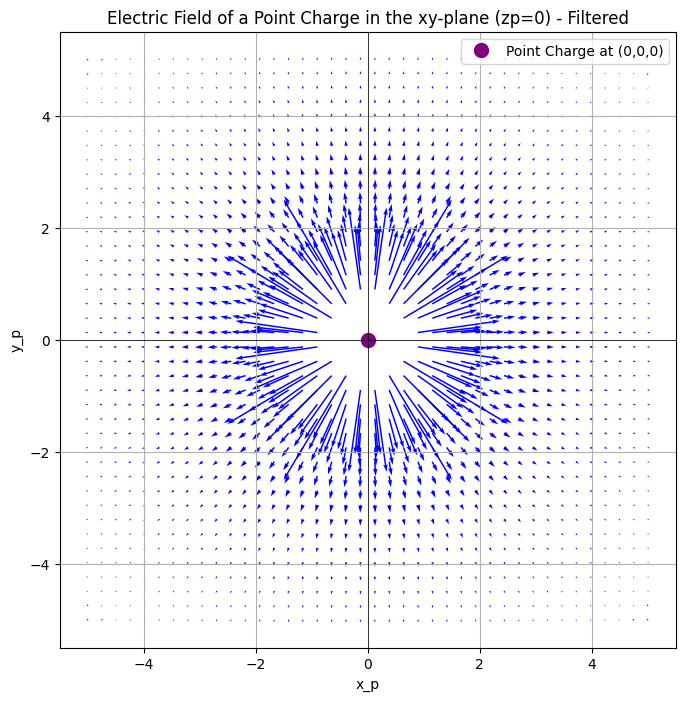

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Define constants for the point charge (from original setting for E_vec)
x_source = 0
y_source = 0
z_source = 0
k_val_point = 1 # k constant
Q_val_point = 1 # Q charge magnitude

# Create a grid for visualization in the xy-plane (zp=0)
x_vals_point = np.linspace(-5, 5, 40)
y_vals_point = np.linspace(-5, 5, 40)
X_point, Y_point = np.meshgrid(x_vals_point, y_vals_point)

# Calculate Ex and Ey components on the grid, keeping zp=0
# The order of arguments for lambdify is [x,y,z,xp,yp,zp,k,Q]
Ex_grid_point = Ex(x_source, y_source, z_source, X_point, Y_point, 0, k_val_point, Q_val_point)
Ey_grid_point = Ey(x_source, y_source, z_source, X_point, Y_point, 0, k_val_point, Q_val_point)

# Calculate electric field magnitude for filtering
E_mag_point = np.sqrt(Ex_grid_point**2 + Ey_grid_point**2)

# Define a threshold for field strength (adjust as needed)
field_strength_threshold = 2.0

# Create a mask for points below the threshold
mask = E_mag_point < field_strength_threshold

# Apply the mask to all relevant arrays
X_point_filtered = X_point[mask]
Y_point_filtered = Y_point[mask]
Ex_grid_point_filtered = Ex_grid_point[mask]
Ey_grid_point_filtered = Ey_grid_point[mask]

# Create the quiver plot with filtered data
plt.figure(figsize=(10, 8))
plt.quiver(X_point_filtered, Y_point_filtered, Ex_grid_point_filtered, Ey_grid_point_filtered, color='blue')

# Add the charge for context
plt.plot(x_source, y_source, 'o', color='purple', markersize=10, label='Point Charge at (0,0,0)')

plt.xlabel('x_p')
plt.ylabel('y_p')
plt.title('Electric Field of a Point Charge in the xy-plane (zp=0) - Filtered')
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

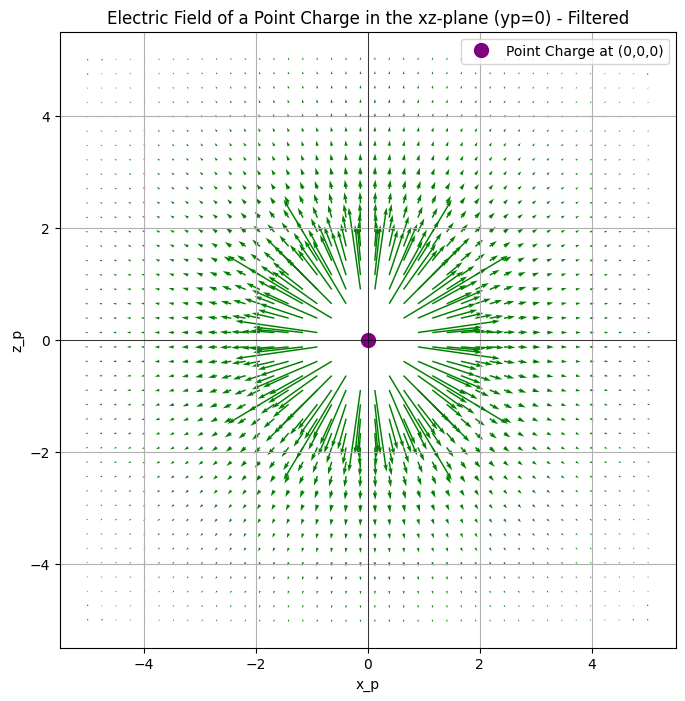

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Define constants for the point charge (from original setting for E_vec)
x_source = 0
y_source = 0
z_source = 0
k_val_point = 1 # k constant
Q_val_point = 1 # Q charge magnitude

# Create a grid for visualization in the xz-plane (yp=0)
x_vals_point = np.linspace(-5, 5, 40)
z_vals_point = np.linspace(-5, 5, 40)
X_point_xz, Z_point_xz = np.meshgrid(x_vals_point, z_vals_point)

# Calculate Ex and Ez components on the grid, keeping yp=0
# The order of arguments for lambdify is [x,y,z,xp,yp,zp,k,Q]
Ex_grid_point_xz = Ex(x_source, y_source, z_source, X_point_xz, 0, Z_point_xz, k_val_point, Q_val_point)
Ez_grid_point_xz = Ez(x_source, y_source, z_source, X_point_xz, 0, Z_point_xz, k_val_point, Q_val_point)

# Calculate electric field magnitude for filtering
E_mag_point_xz = np.sqrt(Ex_grid_point_xz**2 + Ez_grid_point_xz**2)

# Define a threshold for field strength (adjust as needed)
field_strength_threshold = 2.0

# Create a mask for points below the threshold
mask_xz = E_mag_point_xz < field_strength_threshold

# Apply the mask to all relevant arrays
X_point_xz_filtered = X_point_xz[mask_xz]
Z_point_xz_filtered = Z_point_xz[mask_xz]
Ex_grid_point_xz_filtered = Ex_grid_point_xz[mask_xz]
Ez_grid_point_xz_filtered = Ez_grid_point_xz[mask_xz]

# Create the quiver plot with filtered data
plt.figure(figsize=(10, 8))
plt.quiver(X_point_xz_filtered, Z_point_xz_filtered, Ex_grid_point_xz_filtered, Ez_grid_point_xz_filtered, color='green')

# Add the charge for context
plt.plot(x_source, z_source, 'o', color='purple', markersize=10, label='Point Charge at (0,0,0)')

plt.xlabel('x_p')
plt.ylabel('z_p')
plt.title('Electric Field of a Point Charge in the xz-plane (yp=0) - Filtered')
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

## 正負電偶極矩
若有兩個點電荷 $+Q=(a,0,0)$ 及 $-Q=(-a,0,0)$, 則在點$(x_P,y_P,z_P)$的電場向量為
\begin{equation}
\vec{E}(x_p,y_p,z_p)=k\frac{Q((x_p-a)\hat{i}+(y_p)\hat{j}+(z_p)\hat{k})}{((x_p-a)^2+(y_p)^2+(z_p)^2)^{3/2}} \\
- k\frac{Q((x_p+a)\hat{i}+(y_p)\hat{j}+(z_p)\hat{k})}{((x_p+a)^2+(y_p)^2+(z_p)^2)^{3/2}}
\end{equation}

In [38]:
a = sp.symbols('a')
s1_vec = a*C.i + 0*C.j + 0*C.k # source point charge vector for +Q
s2_vec = -a*C.i + 0*C.j + 0*C.k # source point charge vector for -Q
p_vec = xp*C.i + yp*C.j + zp*C.k # observation point vector
r1_vec = p_vec - s1_vec # relative vector for +Q
r2_vec = p_vec - s2_vec # relative vector for -Q

r1_mag = sp.sqrt(r1_vec.dot(r1_vec))
r2_mag = sp.sqrt(r2_vec.dot(r2_vec))
# Define electrical field vector for a dipole (+Q at s1_vec, -Q at s2_vec)
Ed_vec = k*Q*r1_vec/(r1_mag**3) - k*Q*r2_vec/(r2_mag**3)
# show the expression
Ed_vec

(Q*k*(-a + xp)/(yp**2 + zp**2 + (-a + xp)**2)**(3/2) - Q*k*(a + xp)/(yp**2 + zp**2 + (a + xp)**2)**(3/2))*C.i + (-Q*k*yp/(yp**2 + zp**2 + (a + xp)**2)**(3/2) + Q*k*yp/(yp**2 + zp**2 + (-a + xp)**2)**(3/2))*C.j + (-Q*k*zp/(yp**2 + zp**2 + (a + xp)**2)**(3/2) + Q*k*zp/(yp**2 + zp**2 + (-a + xp)**2)**(3/2))*C.k

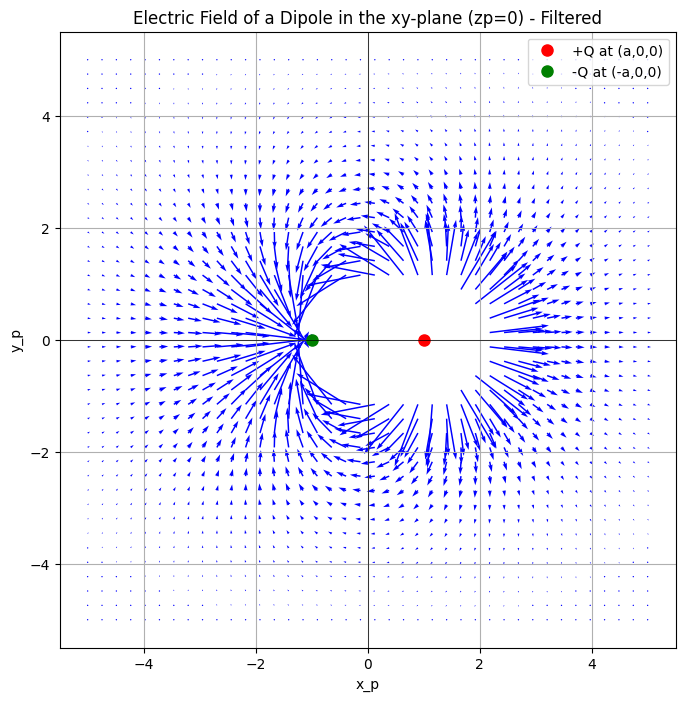

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Define constants from the dipole_setting
a_val = dipole_setting[0] # 'a' for dipole separation
k_val = dipole_setting[4] # k constant
Q_val = dipole_setting[5] # Q charge magnitude

# Create a grid for visualization in the xy-plane (zp=0)
x_vals = np.linspace(-5, 5, 40)
y_vals = np.linspace(-5, 5, 40)
X, Y = np.meshgrid(x_vals, y_vals)

# Calculate Ex and Ey components on the grid, keeping zp=0
# The order of arguments for lambdify is [a,xp,yp,zp,k,Q]
Ex_grid = Ex_dipole(a_val, X, Y, 0, k_val, Q_val)
Ey_grid = Ey_dipole(a_val, X, Y, 0, k_val, Q_val)

# Calculate electric field magnitude for filtering
Ed_mag = np.sqrt(Ex_grid**2 + Ey_grid**2)

# Define a threshold for field strength (can adjust this value)
field_strength_threshold_dipole = 0.8 # Reusing the existing threshold variable, or define new for dipole if needed

# Create a mask for points below the threshold
mask_dipole = Ed_mag < field_strength_threshold_dipole

# Apply the mask to all relevant arrays
X_filtered = X[mask_dipole]
Y_filtered = Y[mask_dipole]
Ex_grid_filtered = Ex_grid[mask_dipole]
Ey_grid_filtered = Ey_grid[mask_dipole]

# Create the quiver plot with filtered data
plt.figure(figsize=(10, 8))
plt.quiver(X_filtered, Y_filtered, Ex_grid_filtered, Ey_grid_filtered, color='blue')

# Add the charges for context
plt.plot(a_val, 0, 'ro', markersize=8, label='+Q at (a,0,0)')
plt.plot(-a_val, 0, 'go', markersize=8, label='-Q at (-a,0,0)')

plt.xlabel('x_p')
plt.ylabel('y_p')
plt.title('Electric Field of a Dipole in the xy-plane (zp=0) - Filtered')
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

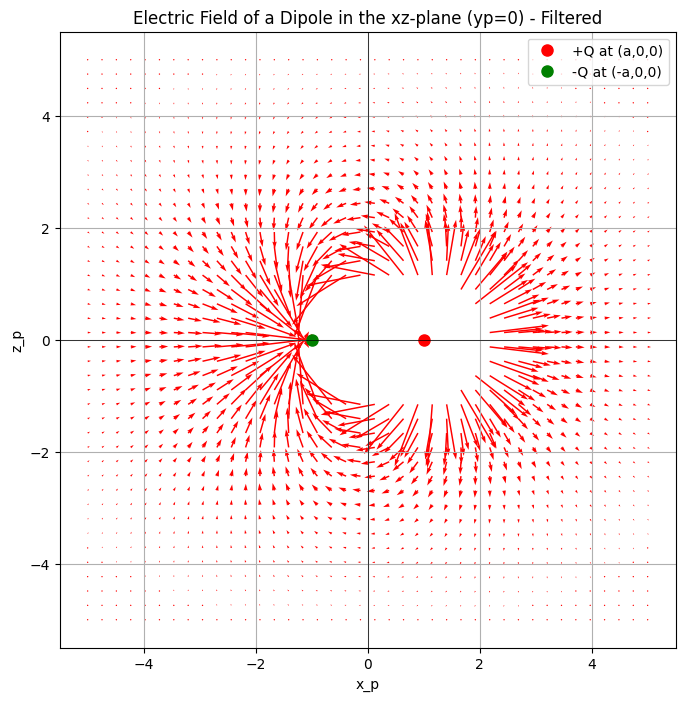

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Define constants from the dipole_setting (assuming they are still in scope)
a_val = dipole_setting[0] # 'a' for dipole separation
k_val = dipole_setting[4] # k constant
Q_val = dipole_setting[5] # Q charge magnitude

# Create a grid for visualization in the xz-plane (yp=0)
x_vals = np.linspace(-5, 5, 40)
z_vals = np.linspace(-5, 5, 40)
X, Z = np.meshgrid(x_vals, z_vals)

# Calculate Ex and Ez components on the grid, keeping yp=0
# The order of arguments for lambdify is [a,xp,yp,zp,k,Q]
Ex_grid_xz = Ex_dipole(a_val, X, 0, Z, k_val, Q_val) # yp is 0
Ez_grid_xz = Ez_dipole(a_val, X, 0, Z, k_val, Q_val) # yp is 0

# Calculate electric field magnitude for filtering
Ed_mag_xz = np.sqrt(Ex_grid_xz**2 + Ez_grid_xz**2)

# Define a threshold for field strength (can adjust this value)
field_strength_threshold_dipole = 0.8 # Reusing the existing threshold variable, or define new for dipole if needed

# Create a mask for points below the threshold
mask_dipole_xz = Ed_mag_xz < field_strength_threshold_dipole

# Apply the mask to all relevant arrays
X_filtered_xz = X[mask_dipole_xz]
Z_filtered_xz = Z[mask_dipole_xz]
Ex_grid_xz_filtered = Ex_grid_xz[mask_dipole_xz]
Ez_grid_xz_filtered = Ez_grid_xz[mask_dipole_xz]

# Create the quiver plot with filtered data
plt.figure(figsize=(10, 8))
plt.quiver(X_filtered_xz, Z_filtered_xz, Ex_grid_xz_filtered, Ez_grid_xz_filtered, color='red')

# Add the charges for context (they are on the x-axis, z=0)
plt.plot(a_val, 0, 'ro', markersize=8, label='+Q at (a,0,0)')
plt.plot(-a_val, 0, 'go', markersize=8, label='-Q at (-a,0,0)')

plt.xlabel('x_p')
plt.ylabel('z_p')
plt.title('Electric Field of a Dipole in the xz-plane (yp=0) - Filtered')
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()